<a href="https://colab.research.google.com/github/zrsteff/DSC502/blob/main/HW3%20-%20Steffens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please see examples we did in class. Questions are just variations of what we did earlier.

**Q1**. Please read WorldCupMatches.csv to a data frame to proceed

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DATA/WorldCupMatches.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA


**Q2** Using seaborn's displot draw density curves to show the distributions of Home Team Goals for every year.

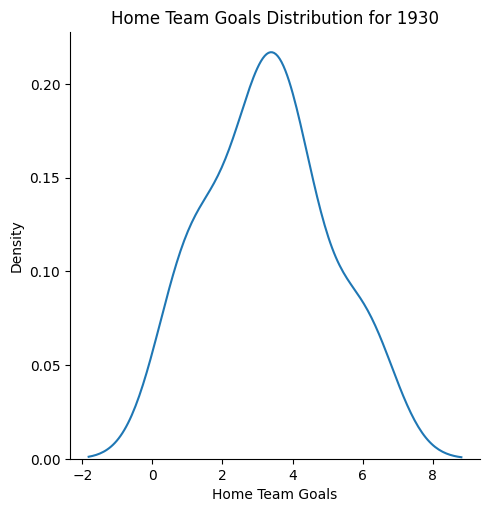

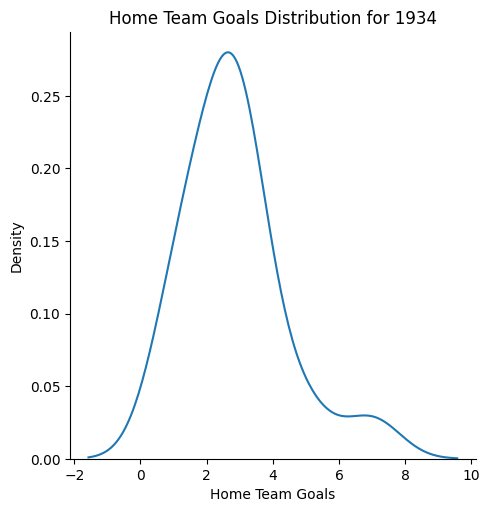

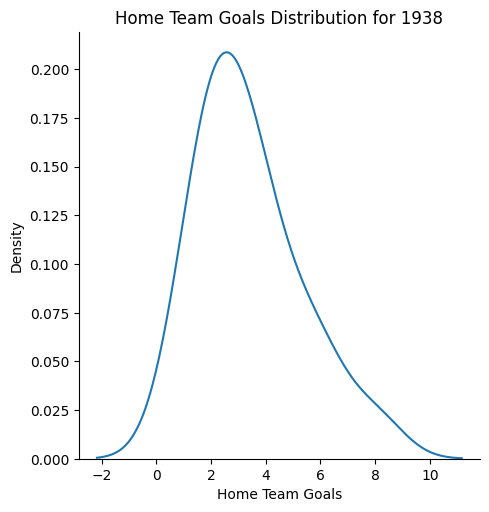

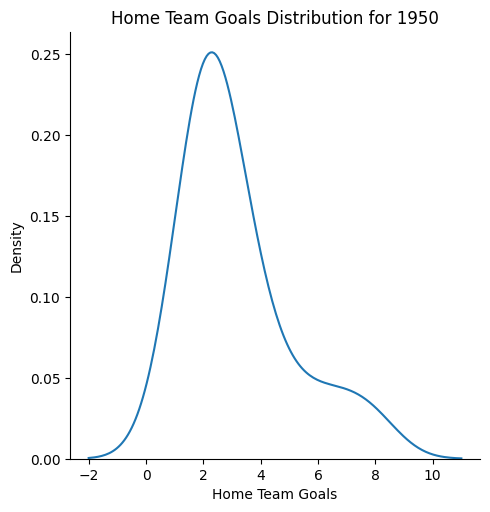

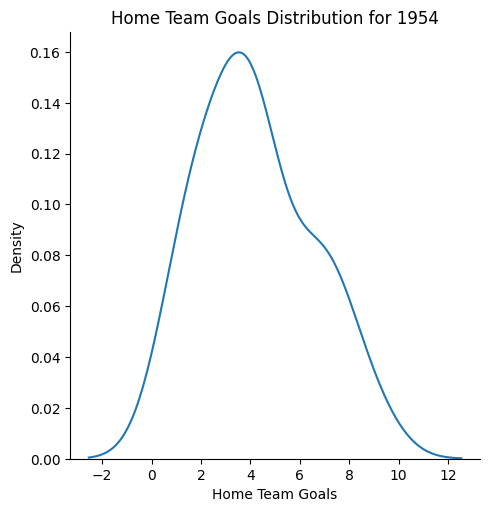

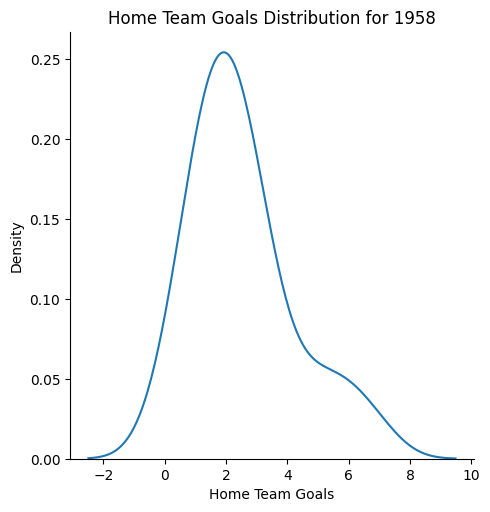

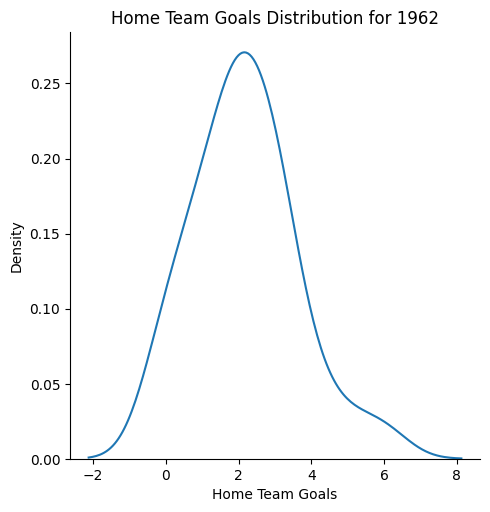

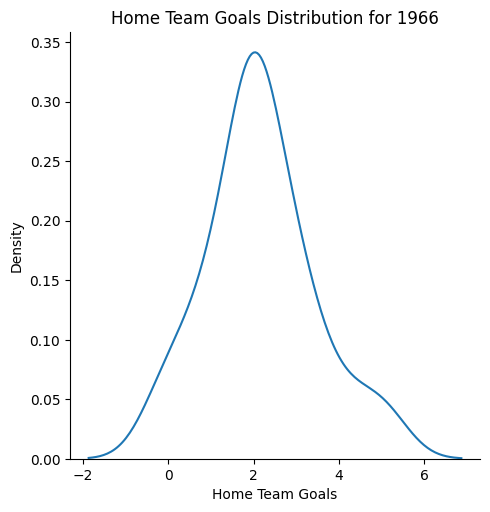

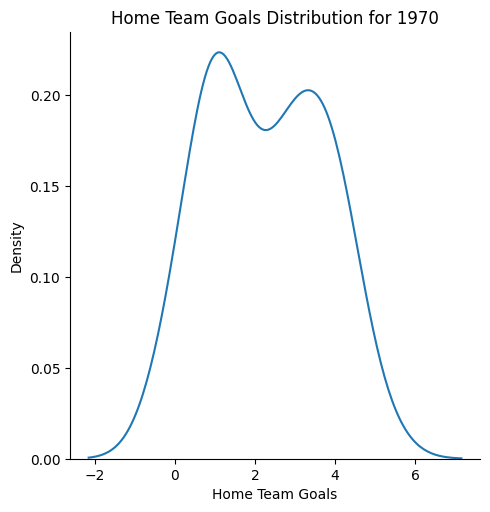

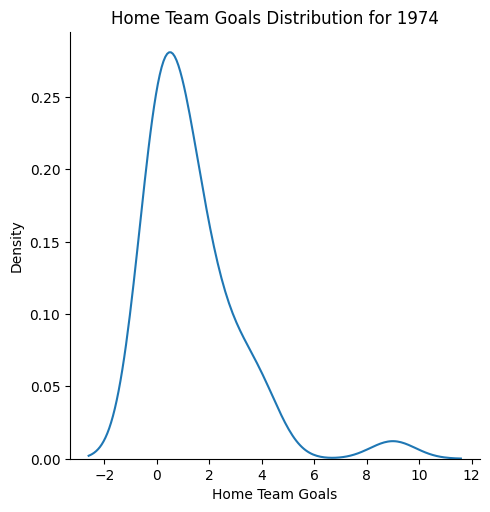

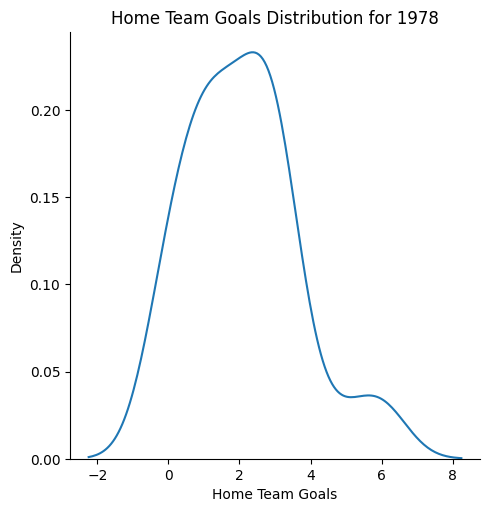

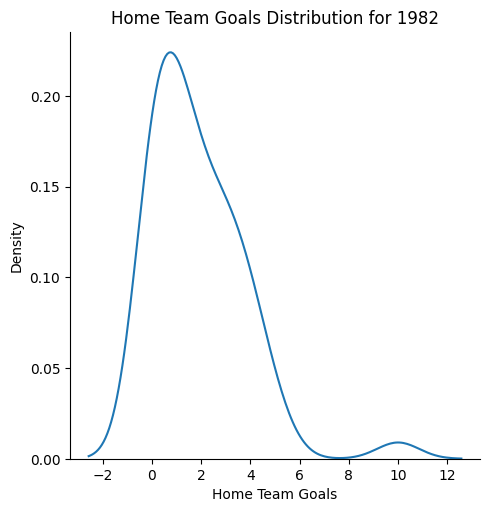

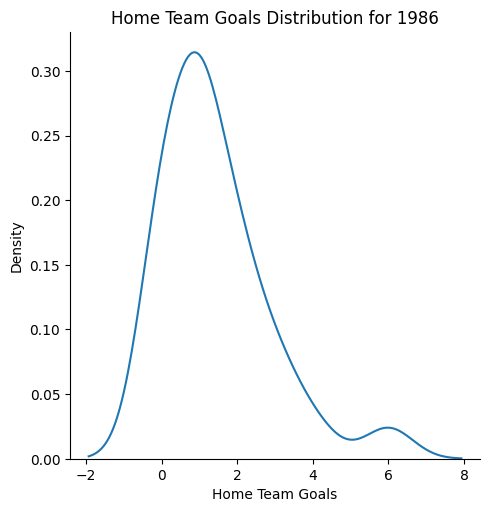

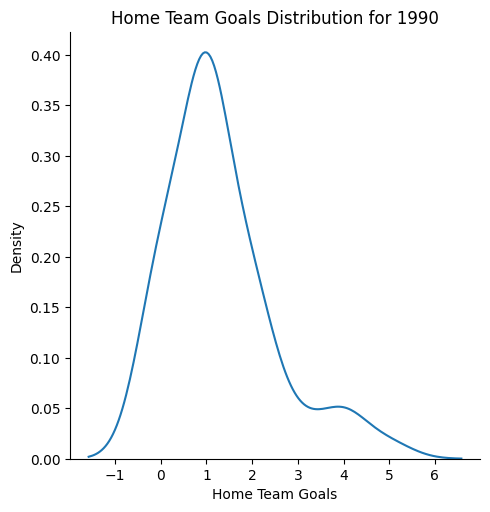

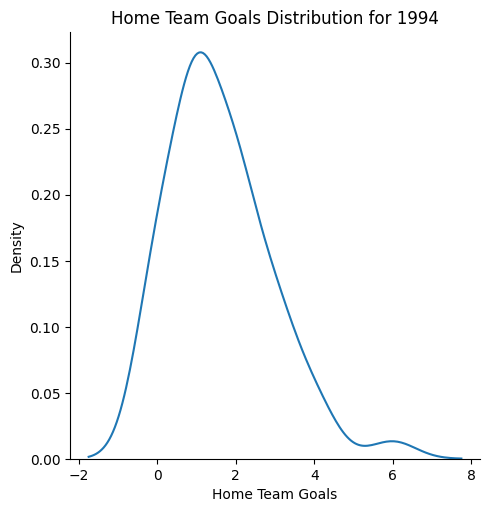

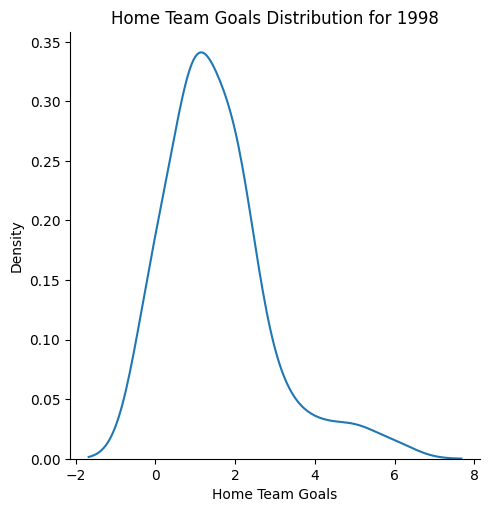

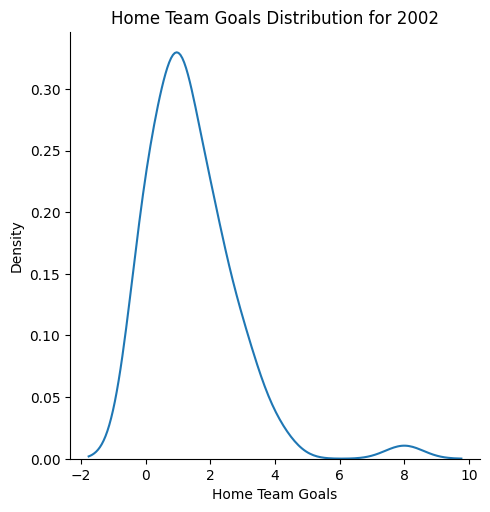

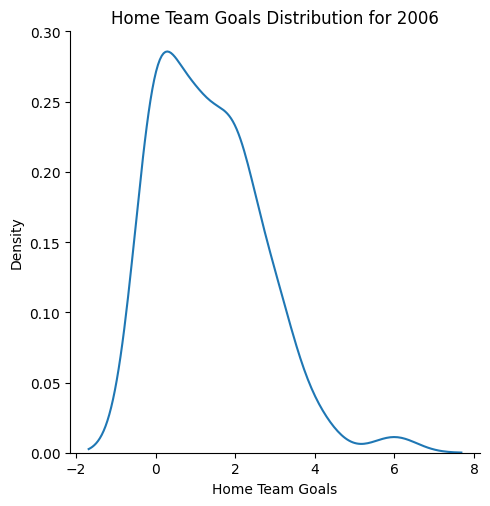

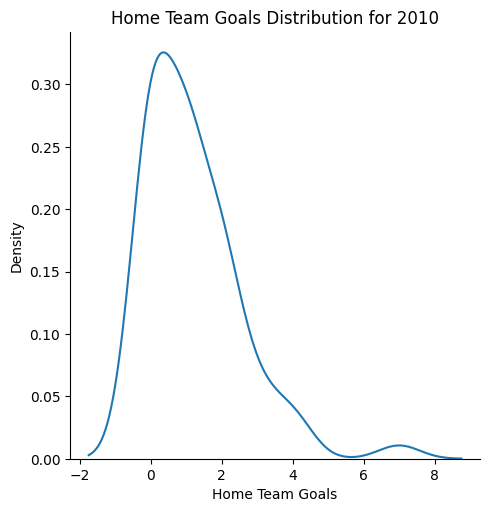

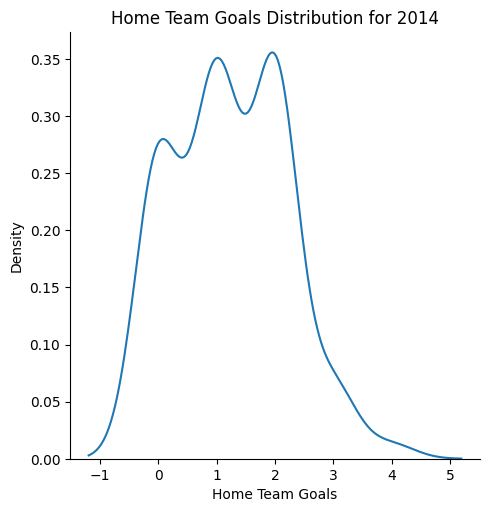

In [7]:
for year in df['Year'].unique():
    sns.displot(df[df['Year'] == year]['Home Team Goals'], kind='kde', label=year)
    plt.title(f'Home Team Goals Distribution for {year}')
    plt.xlabel('Home Team Goals')
    plt.ylabel('Density')
    plt.show()

**Q3** Draw violin plots to summarize Home Team Goals distributions for each year by using seaborn. Notice that labels are really cluttered. Then please refer to the earlier notebooks to have labels to appear on only select years which end with 0. You can use ax handle to call ax.set_xticklables(labels) for the labels your prepared.

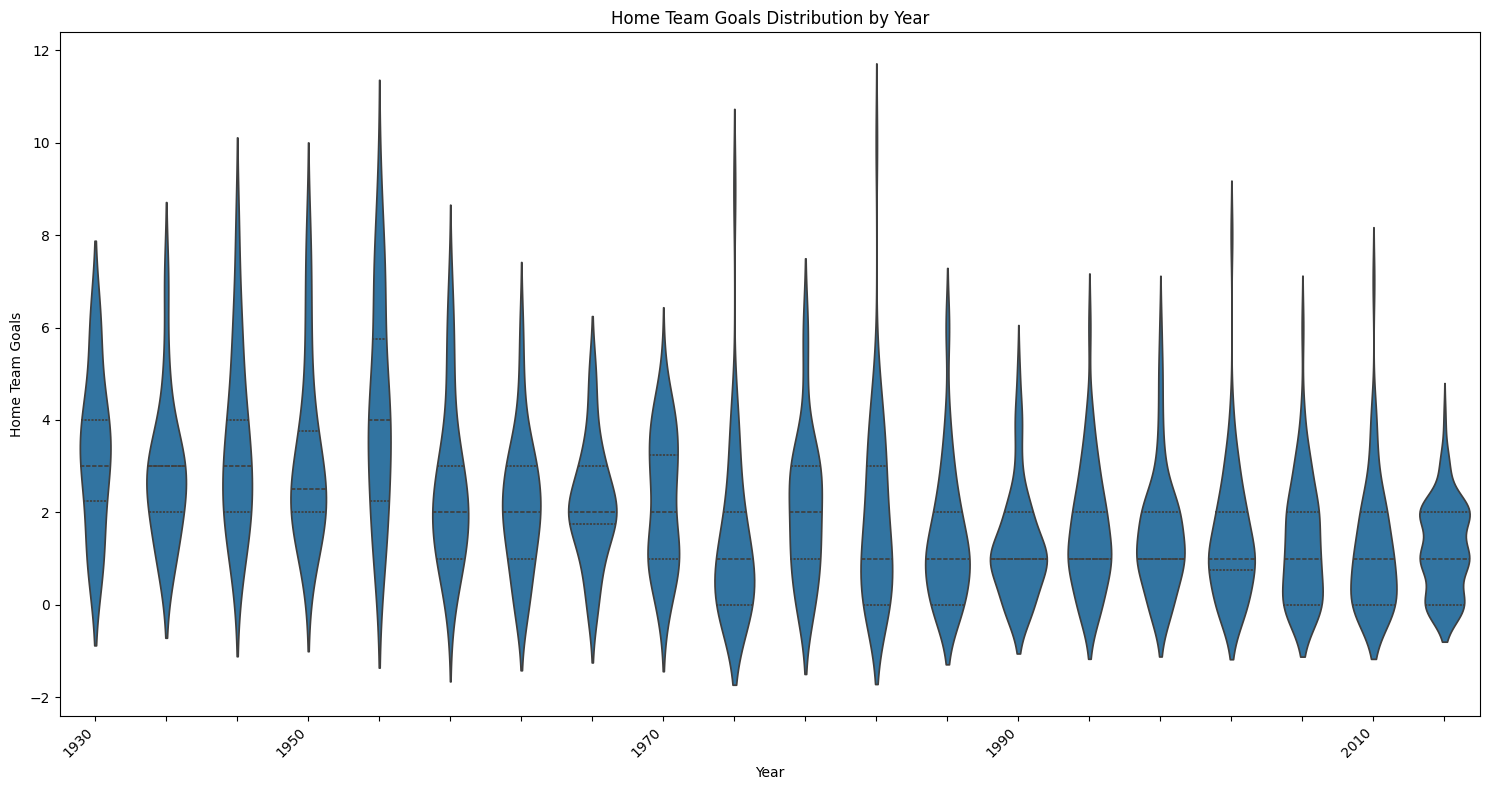

In [9]:
plt.figure(figsize=(15, 8))
sns.violinplot(x='Year', y='Home Team Goals', data=df, inner='quartile')
plt.title('Home Team Goals Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Home Team Goals')

ax = plt.gca()

years = df['Year'].unique()
labels = [year if year % 10 == 0 else '' for year in years]

ax.set_xticks(range(len(years)))
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Q4** Please install joypy. Then visualize distributions for Home Team Goals and Away Team Goals' for each year. Once you visualize, please add  plt.style.use('seaborn-white') to see how colors change in your second run. Please also add the legend which you can find from the function prototype.



Joyplot with default style:


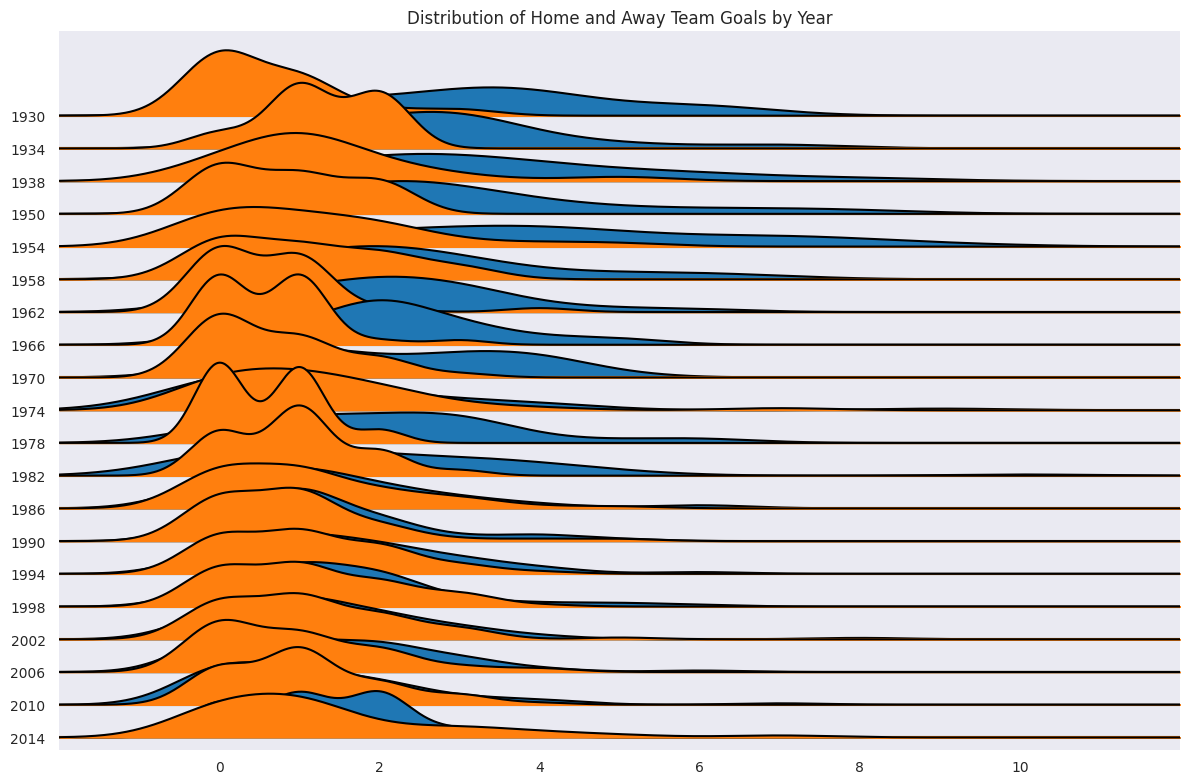

Joyplot with 'seaborn' white style and legend:


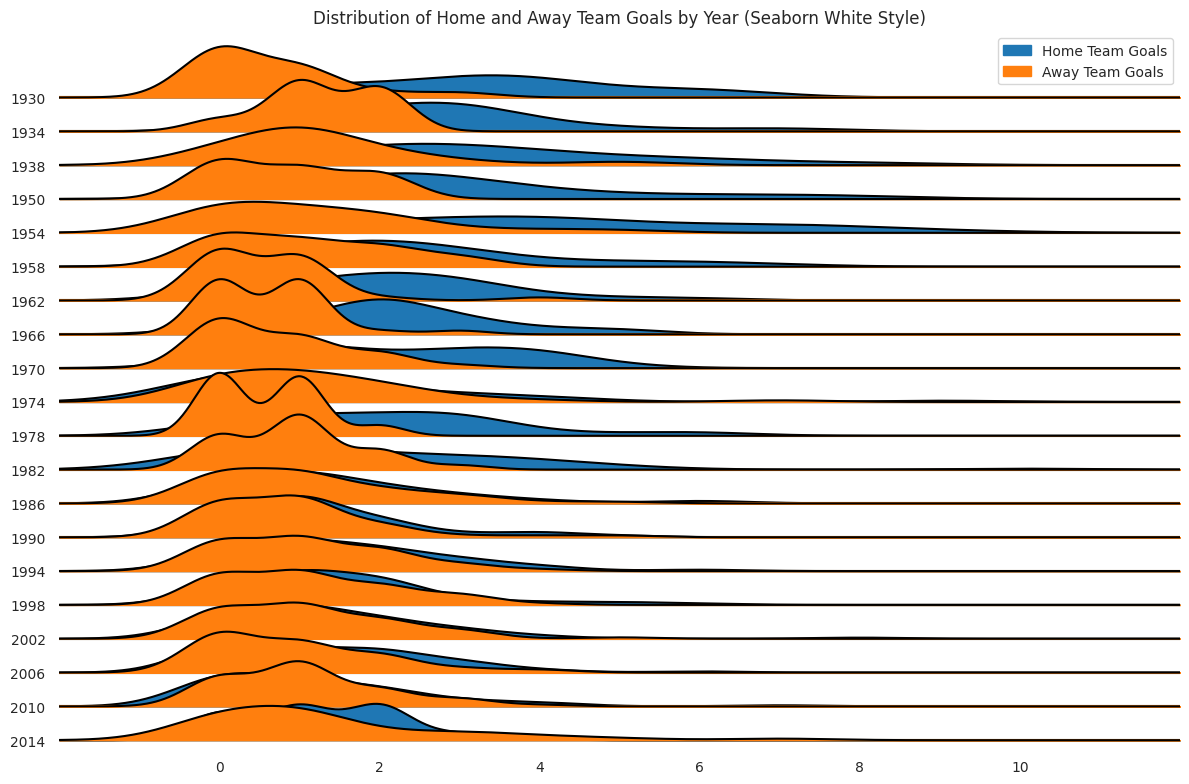

In [17]:
!pip install joypy
import joypy as jp
import matplotlib.pyplot as plt
import seaborn as sns

print("Joyplot with default style:")
fig, axes = jp.joyplot(df, by='Year', column=['Home Team Goals', 'Away Team Goals'],
                       figsize=(12, 8), title='Distribution of Home and Away Team Goals by Year')
plt.show()


print("Joyplot with 'seaborn' white style and legend:")
sns.set_style('white')
fig, axes = jp.joyplot(df, by='Year', column=['Home Team Goals', 'Away Team Goals'],
                       figsize=(12, 8), title='Distribution of Home and Away Team Goals by Year (Seaborn White Style)',
                       legend=True)
plt.show()
sns.set_style('darkgrid')

**Q5** Please use groupby function on Home Team Initials to see the sum of Home Team Goals which can be saved to another data frame by adding .reset_index() end the end of your line.

Then use your new data frame to visualize those total Home Team Goals for your top 5 countries with a bar plot (You can use Home Team Initials). You can use use df.sort_values() function on your data frame by tweaking the ascending option.

Notice that your x-axis will be having country initials, and y-axis will show the total number of Home Team Goals.



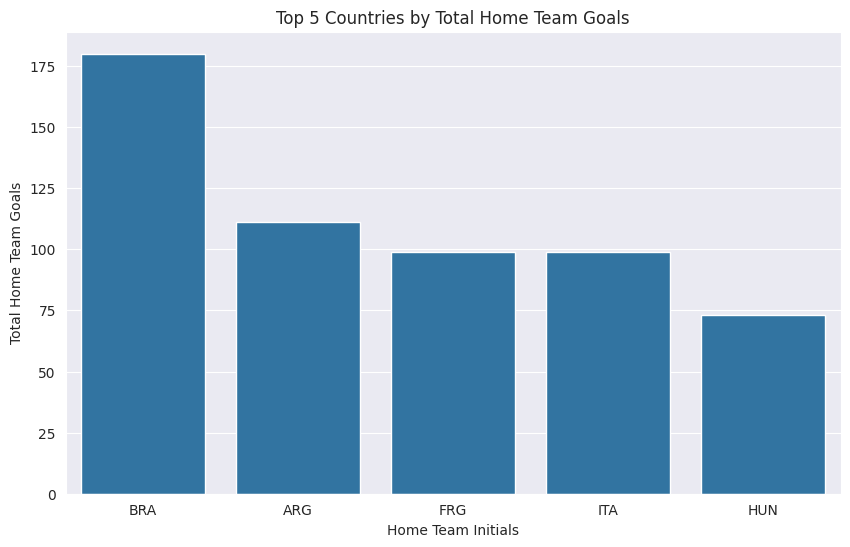

In [23]:
home_goals_by_country = df.groupby('Home Team Initials')['Home Team Goals'].sum().reset_index()

top_5_countries = home_goals_by_country.sort_values(by='Home Team Goals', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Home Team Initials', y='Home Team Goals', data=top_5_countries)
plt.title('Top 5 Countries by Total Home Team Goals')
plt.xlabel('Home Team Initials')
plt.ylabel('Total Home Team Goals')
plt.show()

**Q6** Please extract the rows for your top 4 countries (Home Team Initials') with the help of the previous question's answer. Then use joyplot again to visualize densities for 'Home Team Goals' and	'Away Team Goals' on the horizantal axis. Notice that your y-axis labels will be your country initials (Home Team Initials'). Make sure that your legend is visible and use 'dark_background' by calling plt.style.use again.



Joyplot for Top 4 Countries (Home and Away Team Goals) with 'dark_background' style:


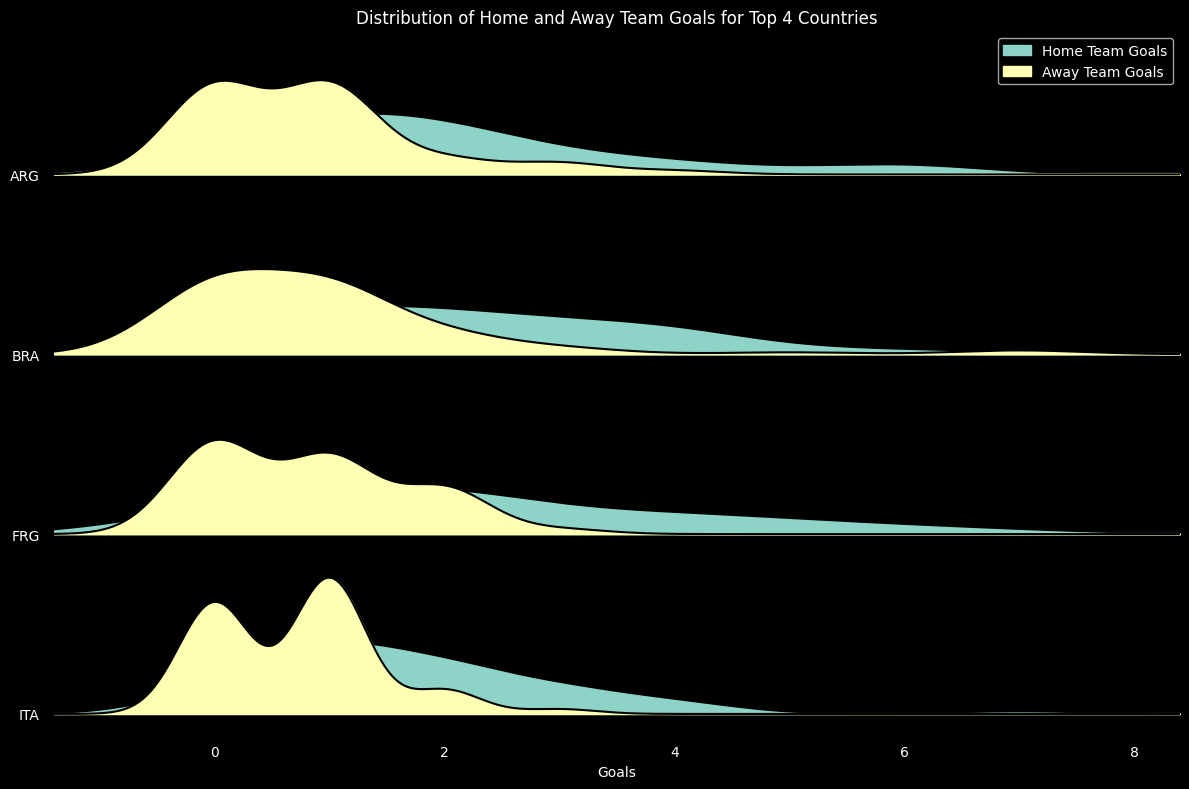

In [24]:
import joypy as jp
import matplotlib.pyplot as plt
import seaborn as sns

top_4_countries_initials = top_5_countries['Home Team Initials'].head(4).tolist()

df_top_4_countries = df[df['Home Team Initials'].isin(top_4_countries_initials)]

plt.style.use('dark_background')

print("Joyplot for Top 4 Countries (Home and Away Team Goals) with 'dark_background' style:")
fig, axes = jp.joyplot(df_top_4_countries, by='Home Team Initials', column=['Home Team Goals', 'Away Team Goals'],
                       figsize=(12, 8),
                       title='Distribution of Home and Away Team Goals for Top 4 Countries',
                       legend=True,
                       overlap=1)
plt.xlabel('Goals')
plt.tight_layout()
plt.show()

plt.style.use('default')

**Q7** Please install seaborn_qqplot as shown below. Then draw a qqplot to compare probability distributions of Home Team Goals and Away Team Goals. Please comment on your finding. Do you think their distributions agree with each other? Please justify your answer by explaining the figure you obtained.

In [25]:
!pip install seaborn_qqplot

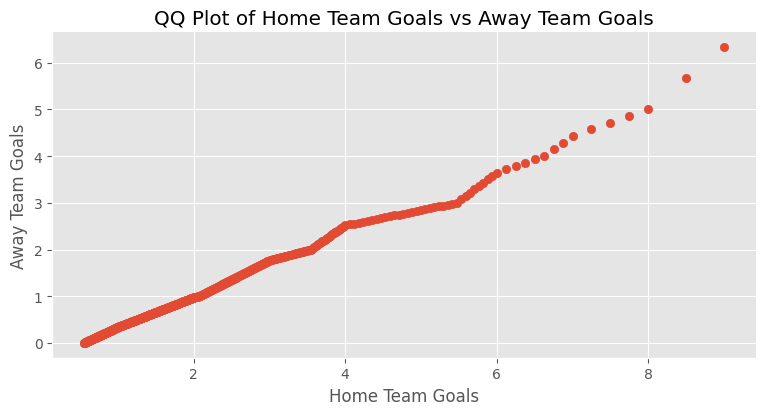


--- Analysis of QQ Plot ---
The QQ plot compares the quantiles of 'Home Team Goals' and 'Away Team Goals'.
If the two distributions were identical, the points would lie perfectly on the identity line (y=x). However, this plot does not display an identity line, so we are looking for a linear relationship between the quantiles.

From the plot, we can observe the following:
1. The points generally follow a roughly linear trend, especially for the middle quantiles. This suggests that the shapes of the distributions for 'Home Team Goals' and 'Away Team Goals' are somewhat similar.
2. There appears to be some deviation from a perfectly straight line, particularly at the tails (lower and higher quantiles). This indicates that the distributions are not exactly the same. For instance, there might be more instances of very low or very high Home Team Goals compared to Away Team Goals, or vice-versa, causing the points to curve away from a perfectly linear path.
3. Without an explicit identity li

In [26]:
from seaborn_qqplot import pplot

plt.style.use('ggplot')

pplot(df, x='Home Team Goals', y='Away Team Goals', kind='qq', display_kws={"identity":False}, height=4, aspect=2)
plt.title('QQ Plot of Home Team Goals vs Away Team Goals')
plt.show()

If the distrubitions were identical, they would perfectly match y = x. The points follow a generally linear trend for the middle quantiles, which suggest the distrubtions for home and away are somewhat similar. However, while they generally agree, there is a notable difference in the tails of the distributions.